# Acne Type Classifier
**EfficientNet-B3 / ResNet-50 — 3-class severity classification**

**Classes:** `acne-comedonica` · `acne-conglobata` · `acne-papulopustulosa`

**Dataset:** Roboflow `Acne type classification v3` — 726 train / 28 test images

---
1. Install & Imports
2. Configuration
3. Dataset Exploration
4. Dataset & DataLoaders
5. Model Definition
6. Training
7. Evaluation
8. Grad-CAM Visualization
9. Inference on a Single Image

## 1. Install & Imports

In [2]:
import os
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import timm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti


## 2. Configuration

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────
DATA_ROOT    = 'acne dataset'
OUTPUT_DIR   = 'outputs'
VAL_FRACTION = 0.15

# ── Model ─────────────────────────────────────────────────────────────
BACKBONE     = 'efficientnet_b3'
PRETRAINED   = True
DROPOUT      = 0.4

# ── Training ──────────────────────────────────────────────────────────
IMAGE_SIZE   = 224
BATCH_SIZE   = 32
EPOCHS       = 40
LR           = 1e-3
WEIGHT_DECAY = 1e-4
FREEZE_EPOCHS = 5

SCHEDULER    = 'cosine'
EARLY_STOP_PATIENCE = 10
IMBALANCE    = 'weighted'

USE_AMP      = True     # Mixed precision — requires CUDA
NUM_WORKERS  = 0        # Keep 0 on Windows Jupyter
SEED         = 42

# ─────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── GPU hard requirement ───────────────────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA not available! This notebook requires a GPU.\n"
        f"  torch.__version__ = {torch.__version__}\n"
        f"  torch.version.cuda = {torch.version.cuda}\n"
        "  Make sure the correct CUDA-enabled PyTorch is installed for your driver."
    )

DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True   # faster convolutions for fixed input size
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"CUDA: {torch.version.cuda}  |  PyTorch: {torch.__version__}")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print('Device:', DEVICE)

GPU : NVIDIA GeForce RTX 5070 Ti
VRAM: 15.9 GB
CUDA: 12.8  |  PyTorch: 2.11.0+cu128
Device: cuda


## 3. Dataset Exploration

Classes (3): ['acne-comedonica', 'acne-conglobata', 'acne-papulopustulosa']
train: {'acne-comedonica': 360, 'acne-conglobata': 192, 'acne-papulopustulosa': 174}  → total 726
test : {'acne-comedonica': 14, 'acne-conglobata': 7, 'acne-papulopustulosa': 7}  → total 28


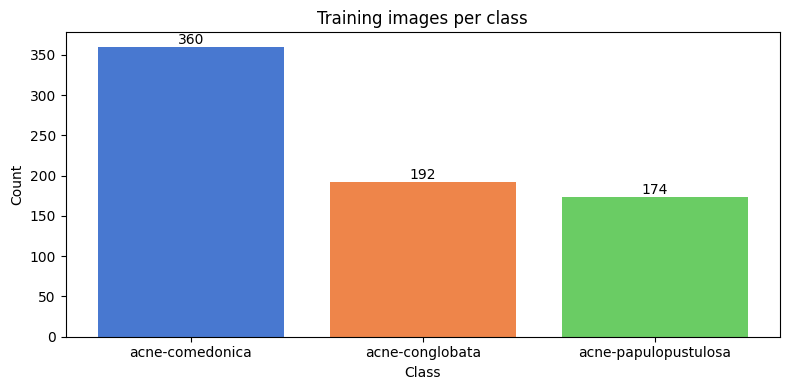

In [4]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def list_images(folder):
    folder = Path(folder)
    return [p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS]

def get_class_names(root, split='train'):
    folder = Path(root) / split
    return sorted([d.name for d in folder.iterdir()
                   if d.is_dir() and not d.name.startswith('.')])

CLASS_NAMES = get_class_names(DATA_ROOT, 'train')
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}):', CLASS_NAMES)

# Count images per split/class
for split in ('train', 'test'):
    counts = {cls: len(list_images(Path(DATA_ROOT) / split / cls))
              for cls in CLASS_NAMES}
    print(f'{split:5s}: {counts}  → total {sum(counts.values())}')

# ── Bar chart ─────────────────────────────────────────────────────────
train_counts = {cls: len(list_images(Path(DATA_ROOT) / 'train' / cls))
                for cls in CLASS_NAMES}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(CLASS_NAMES, train_counts.values(),
              color=sns.color_palette('muted', NUM_CLASSES))
ax.bar_label(bars)
ax.set_title('Training images per class')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

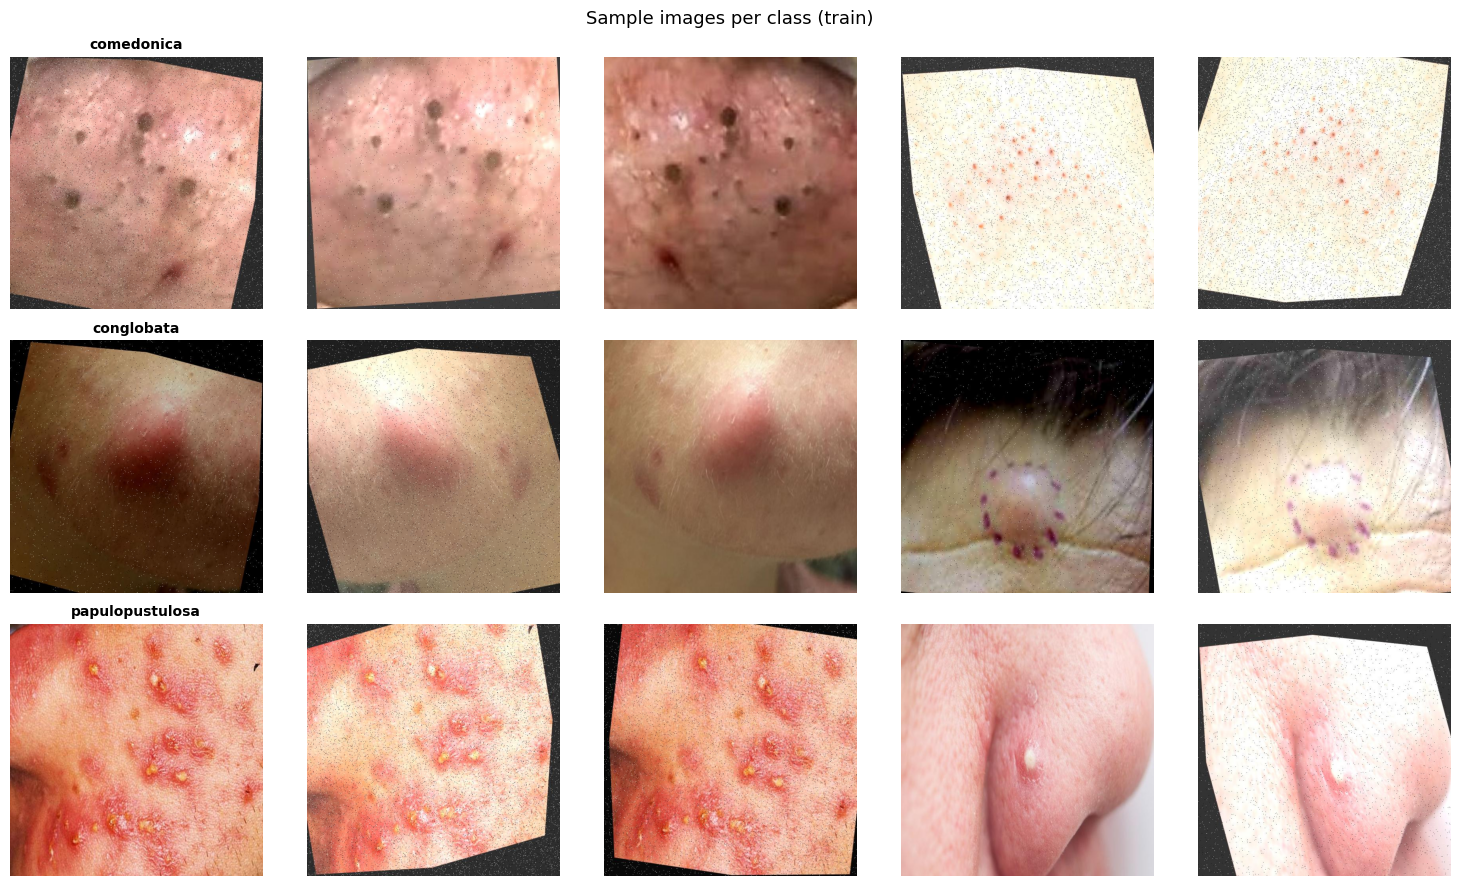

In [5]:
# ── Sample grid: one row per class ────────────────────────────────────
N_PER_CLASS = 5
fig, axes = plt.subplots(NUM_CLASSES, N_PER_CLASS,
                          figsize=(3 * N_PER_CLASS, 3 * NUM_CLASSES))

for row, cls in enumerate(CLASS_NAMES):
    imgs = list_images(Path(DATA_ROOT) / 'train' / cls)[:N_PER_CLASS]
    for col in range(N_PER_CLASS):
        ax = axes[row][col]
        if col < len(imgs):
            ax.imshow(Image.open(imgs[col]).convert('RGB'))
        ax.axis('off')
        if col == 0:
            ax.set_title(cls.replace('acne-', ''), fontsize=10, fontweight='bold')

plt.suptitle('Sample images per class (train)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_grid.png'), dpi=150)
plt.show()

## 4. Dataset & DataLoaders

In [6]:
# ── Build sample lists from train/ (with val holdout) and test/ ───────
def build_samples(root, split, class_names):
    """Returns list of (path_str, label_int)."""
    samples = []
    for label, cls in enumerate(class_names):
        folder = Path(root) / split / cls
        for p in folder.iterdir():
            if p.suffix.lower() in IMG_EXTS:
                samples.append((str(p), label))
    return samples

def split_train_val(samples, val_fraction, seed=42):
    """Stratified split: keeps class balance in val."""
    rng = random.Random(seed)
    by_class = {}
    for path, label in samples:
        by_class.setdefault(label, []).append((path, label))

    train_s, val_s = [], []
    for label, items in by_class.items():
        rng.shuffle(items)
        n_val = max(1, int(len(items) * val_fraction))
        val_s   += items[:n_val]
        train_s += items[n_val:]
    return train_s, val_s


all_train = build_samples(DATA_ROOT, 'train', CLASS_NAMES)
test_samples = build_samples(DATA_ROOT, 'test',  CLASS_NAMES)

train_samples, val_samples = split_train_val(all_train, VAL_FRACTION, SEED)

print(f'Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')
for split_name, slist in [('Train', train_samples), ('Val', val_samples), ('Test', test_samples)]:
    counts = Counter(CLASS_NAMES[l] for _, l in slist)
    print(f'  {split_name}: {dict(counts)}')


# ── Transforms ────────────────────────────────────────────────────────
# NOTE: Roboflow already applied augmentation. We add light additional
# augmentation only — avoid heavy duplicate transforms.
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 20, IMAGE_SIZE + 20)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


# ── Dataset class ─────────────────────────────────────────────────────
class AcneDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


# ── Class weights for imbalance ────────────────────────────────────────
train_labels  = [s[1] for s in train_samples]
label_counts  = Counter(train_labels)
total         = len(train_labels)
class_weights = torch.tensor(
    [total / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float
)
print('\nClass weights:', {CLASS_NAMES[i]: round(float(class_weights[i]), 3)
                           for i in range(NUM_CLASSES)})

sampler       = None
shuffle_train = True
if IMBALANCE == 'oversample':
    sample_weights = [class_weights[l].item() for l in train_labels]
    sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))
    shuffle_train  = False


# ── DataLoaders ───────────────────────────────────────────────────────
train_ds = AcneDataset(train_samples, train_tf)
val_ds   = AcneDataset(val_samples,   val_tf)
test_ds  = AcneDataset(test_samples,  val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=shuffle_train, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'\nBatches → train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

Train: 618 | Val: 108 | Test: 28
  Train: {'acne-comedonica': 306, 'acne-conglobata': 164, 'acne-papulopustulosa': 148}
  Val: {'acne-comedonica': 54, 'acne-conglobata': 28, 'acne-papulopustulosa': 26}
  Test: {'acne-comedonica': 14, 'acne-conglobata': 7, 'acne-papulopustulosa': 7}

Class weights: {'acne-comedonica': 0.673, 'acne-conglobata': 1.256, 'acne-papulopustulosa': 1.392}

Batches → train: 20 | val: 4 | test: 1


## 5. Model Definition

In [7]:
def build_model(backbone: str, num_classes: int,
                pretrained: bool = True, dropout: float = 0.4) -> nn.Module:
    if backbone.startswith('efficientnet'):
        model = timm.create_model(backbone, pretrained=pretrained, num_classes=0)
        in_features = model.num_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    elif backbone.startswith('resnet'):
        weights = 'IMAGENET1K_V1' if pretrained else None
        model   = getattr(models, backbone)(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
    else:
        raise ValueError(f'Unknown backbone: {backbone}')
    return model


def freeze_backbone(model, backbone):
    head_keys = ('classifier', 'fc')
    for name, param in model.named_parameters():
        if not any(k in name for k in head_keys):
            param.requires_grad = False


def unfreeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = True


model = build_model(BACKBONE, NUM_CLASSES, PRETRAINED, DROPOUT).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Backbone   : {BACKBONE}')
print(f'Parameters : {total:,} total | {trainable:,} trainable')

Backbone   : efficientnet_b3
Parameters : 10,700,843 total | 10,700,843 trainable


## 6. Training

In [8]:
# ── Loss, optimizer, scheduler ────────────────────────────────────────
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE) if IMBALANCE == 'weighted' else None
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)

if SCHEDULER == 'cosine':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
elif SCHEDULER == 'step':
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
else:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      patience=5, factor=0.3)

# PyTorch 2.4+: use torch.amp instead of torch.cuda.amp
_amp_enabled = USE_AMP and DEVICE.type == 'cuda'
scaler = torch.amp.GradScaler('cuda', enabled=_amp_enabled)


# ── One-epoch helpers ─────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type=DEVICE.type, enabled=_amp_enabled):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


print('Setup complete — ready to train.')

Setup complete — ready to train.


In [9]:
# ── Main training loop ────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss    = float('inf')
patience_counter = 0
backbone_unfrozen = False

if FREEZE_EPOCHS > 0:
    freeze_backbone(model, BACKBONE)
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Backbone frozen — {t:,} trainable params (head only)\n')

for epoch in range(1, EPOCHS + 1):

    # Unfreeze after FREEZE_EPOCHS: rebuild optimizer with differential LR
    if FREEZE_EPOCHS > 0 and epoch == FREEZE_EPOCHS + 1 and not backbone_unfrozen:
        unfreeze_backbone(model)
        head_keys  = ('classifier', 'fc')
        optimizer  = optim.AdamW([
            {'params': [p for n, p in model.named_parameters()
                        if not any(k in n for k in head_keys)], 'lr': LR / 10},
            {'params': [p for n, p in model.named_parameters()
                        if any(k in n for k in head_keys)],     'lr': LR},
        ], weight_decay=WEIGHT_DECAY)
        if SCHEDULER == 'cosine':
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS - FREEZE_EPOCHS)
        backbone_unfrozen = True
        t = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'Epoch {epoch}: backbone unfrozen — {t:,} trainable params\n')

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss,   val_acc   = eval_epoch (model, val_loader,   criterion)

    if SCHEDULER == 'plateau':
        scheduler.step(val_loss)
    else:
        scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    lr_now = optimizer.param_groups[-1]['lr']
    print(f'Epoch {epoch:3d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f} acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f} acc={val_acc:.4f}  lr={lr_now:.2e}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({'epoch': epoch,
                    'model_state': model.state_dict(),
                    'class_names': CLASS_NAMES,
                    'backbone':    BACKBONE,
                    'val_loss':    val_loss,
                    'val_acc':     val_acc},
                   os.path.join(OUTPUT_DIR, 'best_model.pth'))
        print(f'  ✓ best model saved')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

print('\nTraining complete.')

Backbone frozen — 4,611 trainable params (head only)

Epoch   1/40  train_loss=0.9827 acc=0.5761  val_loss=0.8848 acc=0.7037  lr=9.98e-04
  ✓ best model saved
Epoch   2/40  train_loss=0.8005 acc=0.7168  val_loss=0.7305 acc=0.7685  lr=9.94e-04
  ✓ best model saved
Epoch   3/40  train_loss=0.6758 acc=0.7880  val_loss=0.6612 acc=0.7963  lr=9.86e-04
  ✓ best model saved
Epoch   4/40  train_loss=0.6306 acc=0.7702  val_loss=0.5999 acc=0.8148  lr=9.76e-04
  ✓ best model saved
Epoch   5/40  train_loss=0.6018 acc=0.7961  val_loss=0.5716 acc=0.8056  lr=9.62e-04
  ✓ best model saved
Epoch 6: backbone unfrozen — 10,700,843 trainable params

Epoch   6/40  train_loss=0.4928 acc=0.8285  val_loss=0.3997 acc=0.8981  lr=9.98e-04
  ✓ best model saved
Epoch   7/40  train_loss=0.2917 acc=0.9142  val_loss=0.2484 acc=0.9352  lr=9.92e-04
  ✓ best model saved
Epoch   8/40  train_loss=0.1401 acc=0.9660  val_loss=0.1853 acc=0.9537  lr=9.82e-04
  ✓ best model saved
Epoch   9/40  train_loss=0.0817 acc=0.9854  val_

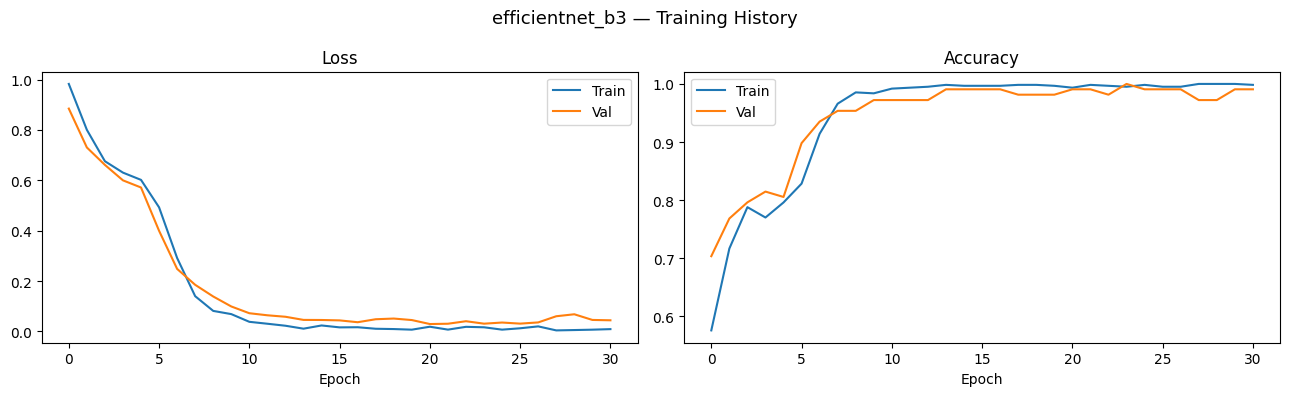

In [10]:
# ── Loss & Accuracy curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle(f'{BACKBONE} — Training History', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 7. Evaluation

In [11]:
# ── Load best checkpoint ──────────────────────────────────────────────
ckpt = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'), map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Best epoch {ckpt['epoch']}  "
      f"val_loss={ckpt['val_loss']:.4f}  val_acc={ckpt['val_acc']:.4f}")


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    preds, labels = [], []
    for imgs, lbs in tqdm(loader, desc='Evaluating'):
        imgs = imgs.to(DEVICE)
        preds.append(model(imgs).argmax(1).cpu())
        labels.append(lbs)
    return torch.cat(preds).numpy(), torch.cat(labels).numpy()


test_preds, test_labels = collect_predictions(model, test_loader)
test_acc = (test_preds == test_labels).mean()
print(f'\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

Best epoch 21  val_loss=0.0296  val_acc=0.9907


Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]


Test Accuracy: 0.9286 (92.9%)

Classification Report:
                      precision    recall  f1-score   support

     acne-comedonica       1.00      0.86      0.92        14
     acne-conglobata       0.88      1.00      0.93         7
acne-papulopustulosa       0.88      1.00      0.93         7

            accuracy                           0.93        28
           macro avg       0.92      0.95      0.93        28
        weighted avg       0.94      0.93      0.93        28



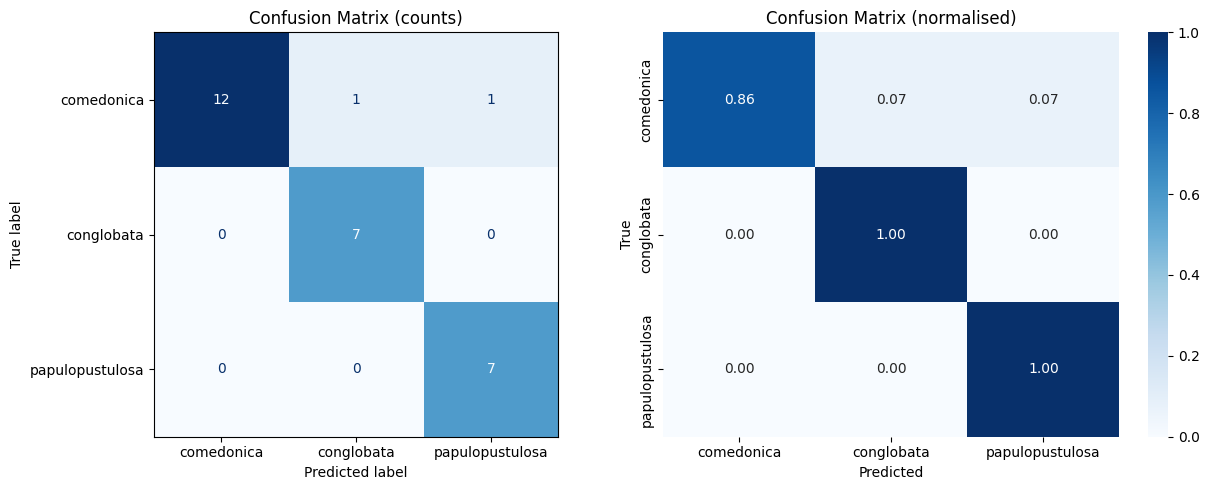

In [12]:
# ── Confusion matrices ────────────────────────────────────────────────
SHORT = [c.replace('acne-', '') for c in CLASS_NAMES]
cm    = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=SHORT).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (counts)')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=SHORT, yticklabels=SHORT, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalised)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 8. Grad-CAM Visualization

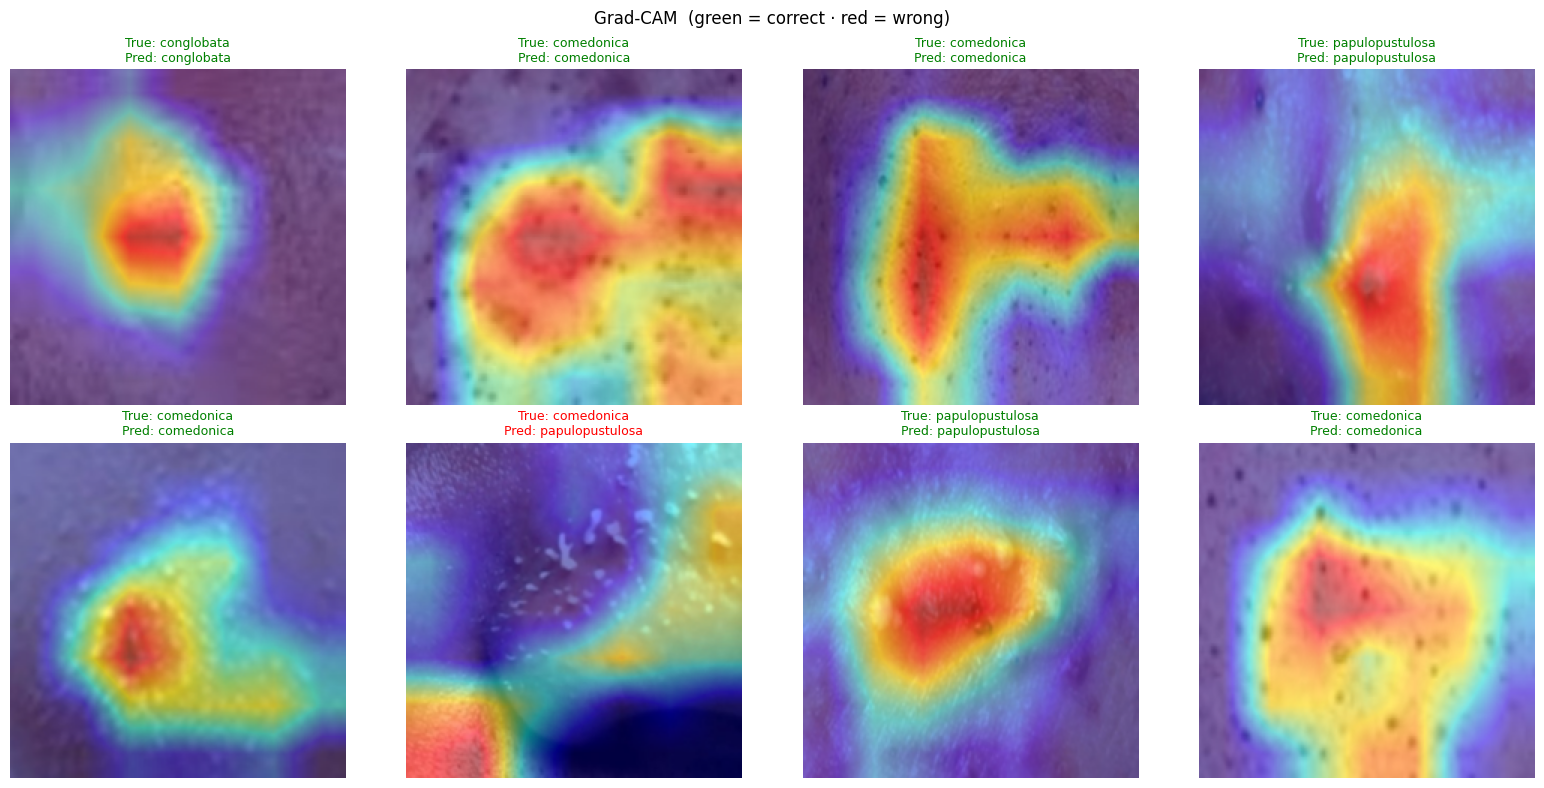

In [13]:
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    GRADCAM_OK = True
except ImportError:
    GRADCAM_OK = False
    print('grad-cam not found. Run: pip install grad-cam')


def get_target_layer(model, backbone):
    if backbone.startswith('efficientnet'):
        return [model.blocks[-1]]
    return [model.layer4[-1]]   # resnet


if GRADCAM_OK:
    cam    = GradCAM(model=model, target_layers=get_target_layer(model, BACKBONE))
    n_show = min(8, len(test_ds))
    idxs   = random.sample(range(len(test_ds)), n_show)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    model.eval()

    for i, idx in enumerate(idxs):
        img_t, true_lbl = test_ds[idx]
        inp = img_t.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = model(inp).argmax(1).item()

        grayscale = cam(inp, targets=[ClassifierOutputTarget(pred)])[0]

        raw = img_t.permute(1, 2, 0).numpy()
        raw = np.clip(raw * np.array(STD) + np.array(MEAN), 0, 1).astype(np.float32)
        overlay = show_cam_on_image(raw, grayscale, use_rgb=True)

        axes[i].imshow(overlay)
        colour = 'green' if pred == true_lbl else 'red'
        axes[i].set_title(
            f"True: {CLASS_NAMES[true_lbl].replace('acne-','')}\n"
            f"Pred: {CLASS_NAMES[pred].replace('acne-','')}",
            color=colour, fontsize=9
        )
        axes[i].axis('off')

    plt.suptitle('Grad-CAM  (green = correct · red = wrong)', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gradcam.png'), dpi=150)
    plt.show()

## 9. Inference on a Single Image

Ground truth : acne-papulopustulosa


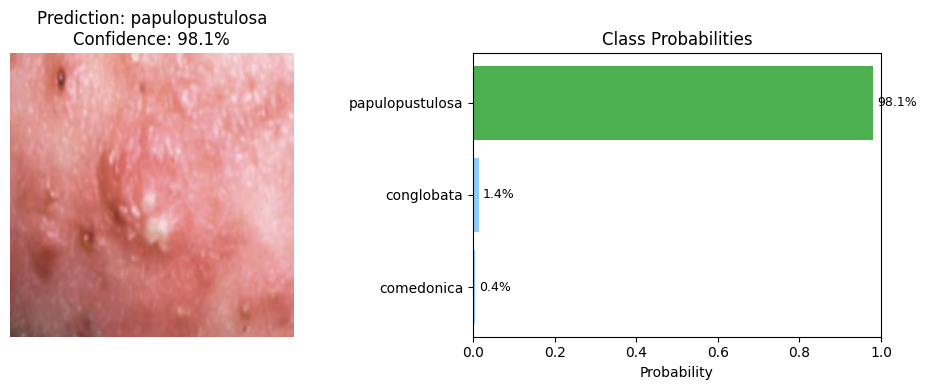

{'predicted_class': 'acne-papulopustulosa', 'confidence': 0.9813411235809326, 'probabilities': {'acne-comedonica': 0.004265990108251572, 'acne-conglobata': 0.014392940327525139, 'acne-papulopustulosa': 0.9813411235809326}}


In [14]:
def predict(image_path: str) -> dict:
    """
    Predict acne type for a single image.
    Returns {'predicted_class', 'confidence', 'probabilities'}.
    """
    model.eval()
    img = Image.open(image_path).convert('RGB')
    inp = val_tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs = torch.softmax(model(inp), dim=1).squeeze().cpu().numpy()

    pred_idx   = probs.argmax()
    confidence = probs[pred_idx]
    result     = {
        'predicted_class': CLASS_NAMES[pred_idx],
        'confidence':      float(confidence),
        'probabilities':   {c: float(p) for c, p in zip(CLASS_NAMES, probs)},
    }

    # Display
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(
        f"Prediction: {result['predicted_class'].replace('acne-','')}\n"
        f"Confidence: {confidence:.1%}", fontsize=12
    )
    short_names = [c.replace('acne-', '') for c in CLASS_NAMES]
    colours = ['#4CAF50' if i == pred_idx else '#90CAF9' for i in range(NUM_CLASSES)]
    ax2.barh(short_names, probs, color=colours)
    ax2.set_xlim(0, 1)
    ax2.set_xlabel('Probability')
    ax2.set_title('Class Probabilities')
    for i, p in enumerate(probs):
        ax2.text(p + 0.01, i, f'{p:.1%}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    return result


# ── Demo: random image from test set ──────────────────────────────────
sample_path, sample_label = random.choice(test_samples)
print(f'Ground truth : {CLASS_NAMES[sample_label]}')
result = predict(sample_path)
print(result)